# Clasificador SVM clásico

Clasificación binaria sobre el dataset Iris usando una Máquina de Vectores de Soporte (SVM) con kernel RBF.

Este notebook entrena el modelo clásico de referencia y guarda los resultados en `svm_results.json`  
para su uso posterior en `comparison/comparison.ipynb`.

**Variable de configuración:** `N_FEATURES` controla cuántas features se usan (2 o 4).  
Para la versión de 4 features, los resultados se guardan automáticamente en `svm_results_4f.json`.

## Imports

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Configuración

Cambiar `N_FEATURES` a 4 para ejecutar el experimento con 4 características.  
Todo el resto del notebook se adapta automáticamente.

In [ ]:
N_FEATURES  = 2          # 2 or 4
TEST_SIZE   = 0.2        # fraction of data held out for testing
RANDOM_SEED = 42         # reproducibility

RESULTS_FILE = "svm_results.json" if N_FEATURES == 2 else "svm_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, TEST_SIZE={TEST_SIZE}")
print(f"Results will be saved to: {RESULTS_FILE}")

Configuration: N_FEATURES=2, TEST_SIZE=0.2
Results will be saved to: svm_results.json


## Dataset

Se usa el dataset Iris restringido a **2 clases** (Versicolor vs Virginica, clases 1 y 2).  
La clase 0 (Setosa) se descarta porque es linealmente separable y trivialmente fácil,
daría una precisión artificialmente alta que ocultaría la comparación real.

Features usadas:
- `N_FEATURES = 2`: longitud del pétalo, anchura del pétalo (features 2 y 3, el par más discriminativo)
- `N_FEATURES = 4`: las cuatro features (longitud del sépalo, anchura del sépalo, longitud del pétalo, anchura del pétalo)

Todas las features se escalan a [0, 1] con `MinMaxScaler`. El circuito cuántico aplicará  
el mismo escalado para que ambos modelos reciban entradas idénticas.

In [3]:
iris = load_iris()

# Keep only classes 1 and 2
mask     = iris.target != 0
X_full   = iris.data[mask]
y_full   = iris.target[mask] - 1      # remap to {0, 1}

# Feature selection
if N_FEATURES == 2:
    X = X_full[:, 2:4]                # petal length, petal width
    feature_names = ["petal length", "petal width"]
else:
    X = X_full                        # all 4 features
    feature_names = list(iris.feature_names)

# Scale to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")
print(f"Class balance (train): {np.bincount(y_train)}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['petal length', 'petal width']
Class balance (train): [40 40]


## Algoritmo clásico - SVM con kernel RBF

Una Máquina de Vectores de Soporte busca el hiperplano que maximiza el margen entre clases.  
El kernel RBF (Función de Base Radial) mapea implícitamente la entrada a un espacio de mayor dimensión,  
permitiendo fronteras de decisión no lineales.

Este es el contrapunto clásico natural al VQC: ambos son métodos basados en kernel;  
la diferencia es que el VQC usa un circuito cuántico para calcular su kernel.

In [4]:
def train_svm(X_train, y_train):
    """Train an SVM with RBF kernel. Returns the fitted model and elapsed training time."""
    model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_SEED)
    t0    = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    return model, elapsed


def evaluate_model(model, X_train, y_train, X_test, y_test, X_scaled, y_full):
    """Evaluate the model and return a metrics dict."""
    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    acc_test  = accuracy_score(y_test,  y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)

    # 5-fold cross-validation on the full scaled dataset
    cv_scores = cross_val_score(model, X_scaled, y_full, cv=5, scoring="accuracy")

    return {
        "accuracy_test"  : float(acc_test),
        "accuracy_train" : float(acc_train),
        "cv_mean"        : float(cv_scores.mean()),
        "cv_std"         : float(cv_scores.std()),
        "cv_scores"      : cv_scores.tolist(),
        "y_pred_test"    : y_pred_test.tolist(),
        "y_test"         : y_test.tolist(),
    }

## Ejecución

In [5]:
svm_model, train_time = train_svm(X_train, y_train)
metrics               = evaluate_model(svm_model, X_train, y_train, X_test, y_test, X_scaled, y_full)

print(f"Training time : {train_time:.4f} s")
print(f"Test accuracy : {metrics['accuracy_test']:.4f}")
print(f"Train accuracy: {metrics['accuracy_train']:.4f}")
print(f"CV accuracy   : {metrics['cv_mean']:.4f} ± {metrics['cv_std']:.4f}")
print()
print(classification_report(metrics['y_test'], metrics['y_pred_test'],
                             target_names=["Versicolor", "Virginica"]))

Training time : 0.0032 s
Test accuracy : 0.8500
Train accuracy: 0.9750
CV accuracy   : 0.9400 ± 0.0374

              precision    recall  f1-score   support

  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



## Gráficas

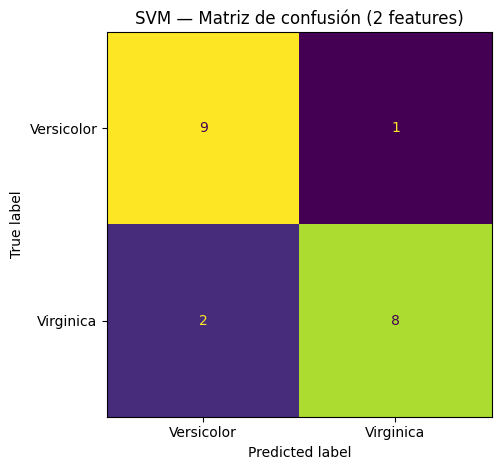

In [ ]:
# Confusion matrix 
cm = confusion_matrix(metrics['y_test'], metrics['y_pred_test'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"SVM — Matriz de confusión ({N_FEATURES} características)")
plt.tight_layout()
plt.savefig(f"svm_confusion_matrix{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

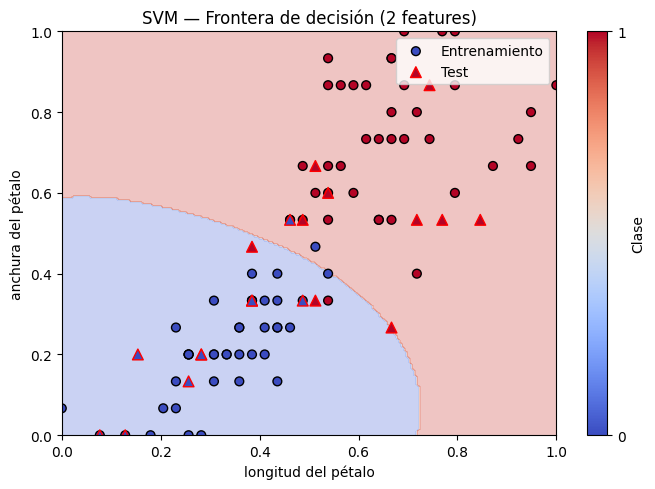

In [ ]:
# Decision boundary (only for 2 features) 
if N_FEATURES == 2:
    h = 0.005
    xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    _es = {
        "petal length"    : "longitud del pétalo",
        "petal width"     : "anchura del pétalo",
        "sepal length (cm)": "longitud del sépalo (cm)",
        "sepal width (cm)" : "anchura del sépalo (cm)",
        "petal length (cm)": "longitud del pétalo (cm)",
        "petal width (cm)" : "anchura del pétalo (cm)",
    }

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    sc = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                     cmap="coolwarm", vmin=0, vmax=1,
                     edgecolors="k", s=40, label="Entrenamiento")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", vmin=0, vmax=1,
                edgecolors="r", s=60, marker="^", label="Prueba")
    plt.colorbar(sc, ticks=[0, 1], label="Clase")
    plt.xlabel(_es.get(feature_names[0], feature_names[0]))
    plt.ylabel(_es.get(feature_names[1], feature_names[1]))
    plt.title("SVM — Frontera de decisión (2 características)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("svm_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Gráfica de frontera de decisión omitida (solo disponible para N_FEATURES=2).")

## Guardar resultados

Todas las métricas se guardan en `svm_results.json` (o `svm_results_4f.json` para 4 características).  
El notebook de comparación carga este archivo directamente, no es necesario volver a entrenar.

In [ ]:
results = {
    # Experiment metadata 
    "model"         : "SVM-RBF",
    "n_features"    : N_FEATURES,
    "feature_names" : feature_names,
    "n_train"       : int(len(X_train)),
    "n_test"        : int(len(X_test)),
    "random_seed"   : RANDOM_SEED,

    # Timing 
    "train_time_s"  : float(train_time),

    # Accuracy
    "accuracy_test" : metrics["accuracy_test"],
    "accuracy_train": metrics["accuracy_train"],
    "cv_mean"       : metrics["cv_mean"],
    "cv_std"        : metrics["cv_std"],
    "cv_scores"     : metrics["cv_scores"],

    # Predictions (for confusion matrix in comparison notebook)
    "y_test"        : metrics["y_test"],
    "y_pred_test"   : metrics["y_pred_test"],
    
    # SVM-specific 
    "n_support_vectors": int(sum(svm_model.n_support_)),
    "svm_C"            : svm_model.C,
    "svm_gamma"        : svm_model.gamma,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
print(json.dumps({k: v for k, v in results.items() if k not in ("cv_scores", "y_test", "y_pred_test")}, indent=2))

Results saved to svm_results.json
{
  "model": "SVM-RBF",
  "n_features": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "train_time_s": 0.0031694909994257614,
  "accuracy_test": 0.85,
  "accuracy_train": 0.975,
  "cv_mean": 0.9399999999999998,
  "cv_std": 0.037416573867739396,
  "n_support_vectors": 17,
  "svm_C": 1.0,
  "svm_gamma": "scale"
}
